# Deep Dive Analysis: Statistical Significance & Visual Performance

Notebook ini menggabungkan analisis statistik mendalam dengan visualisasi performa per tahun. Fokus utama:
1. **Performance Visualization**: Menampilkan equity curve untuk setiap tahun (2023, 2024, 2025).
2. **Metric Comparison**: Bar charts untuk perbandingan return, sharpe, volatility, dan drawdown.
3. **Statistical Significance**: T-Test untuk membuktikan validitas perbedaan performa.
4. **Asset Portfolio Analysis**: Bedah komposisi aset strategi Cluster di tahun 2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Load Data & Setup

In [2]:
# Load cryptocurrency data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")

Data: 990 rows, 25 assets


## 2. Model Training & Probabilities

In [3]:
# Prepare features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Train model (up to 2024)
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Threshold Optimization
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
f_scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in thresholds]
opt_t = thresholds[np.argmax(f_scores)]

# Probabilities for backtest
X_all = features.dropna()
all_probs = pd.Series(xgb_model.predict_proba(X_all)[:, 1], index=X_all.index)
all_probs = all_probs.reindex(returns.index, method='ffill').fillna(method='bfill')

print(f"✓ AI Ready. Opt Threshold: {opt_t:.2f}")

✓ AI Ready. Opt Threshold: 0.54


## 3. Simulation Functions

In [4]:
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    res = minimize(objective, [1./num_assets]*num_assets, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) < corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, selection_func, override_ma=200, fee=0.0025):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {}
    risk_status = False
    days_since_rebal = 999
    alloc_hist = {}
    market_ma = market_idx.rolling(window=override_ma).mean() if override_ma else None

    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk_status = risk_status
        
        # Hysteresis + Trend Override
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): ai_signal = True
        elif risk_status and prob < (threshold - buffer): ai_signal = False
        else: ai_signal = risk_status
        
        final_signal = ai_signal
        if market_ma is not None:
            try:
                if market_idx.loc[date] > market_ma.loc[date]: final_signal = True
            except: pass
            
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        target_weights = current_weights.copy()
        
        if not risk_status:
            target_weights = {'CASH': 1.0}
            days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= 20:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window = returns.iloc[max(0, loc_idx-60):loc_idx]
                    selected = selection_func(window)
                    if selected:
                        target_weights = optimize_markowitz(window[selected])
                        days_since_rebal = 0
                except: pass
        
        days_since_rebal += 1
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in set(target_weights)|set(current_weights))
        val -= val * turnover * fee
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_drifted = {}
        if 'CASH' in target_weights: 
            new_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                r = returns.loc[next_date, asset] if next_date in returns.index else 0
                day_ret += w * r
                new_drifted[asset] = w * (1 + r)
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = {k: v/sum(new_drifted.values()) for k, v in new_drifted.items()} if sum(new_drifted.values()) > 0 else new_drifted
        alloc_hist[date] = target_weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), alloc_hist

def run_simulation_static(test_dates, returns):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    for i, date in enumerate(test_dates[:-1]):
        next_date = test_dates[i+1]
        day_ret = returns.loc[next_date].mean()
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

## 4. Run Backtests & Calculate Metrics

In [5]:
years = [2023, 2024, 2025]
results = {}
metrics_list = []

for year in years:
    print(f"Simulating {year}...")
    test_dates = returns.loc[returns.index.year == year].index
    
    div_val, div_alloc = run_simulation_ai_gated(test_dates, returns, all_probs, opt_t, market_index, get_assets_graph_diversify)
    cls_val, cls_alloc = run_simulation_ai_gated(test_dates, returns, all_probs, opt_t, market_index, get_assets_graph_cluster)
    static_val = run_simulation_static(test_dates, returns)
    
    results[year] = {
        'Diversify': {'value': div_val, 'alloc': div_alloc},
        'Cluster': {'value': cls_val, 'alloc': cls_alloc},
        'Static': {'value': static_val}
    }
    
    # Calc Metrics
    for name, df_obj in [('Diversify', div_val), ('Cluster', cls_val), ('Static', static_val)]:
        v = df_obj['Portfolio_Value']
        ret = (v.iloc[-1] / v.iloc[0] - 1) * 100
        daily_rets = v.pct_change().dropna()
        vol = daily_rets.std() * np.sqrt(252) * 100
        sharpe = (ret / vol) if vol > 0 else 0
        mdd = ((v - v.cummax()) / v.cummax() * 100).min()
        
        metrics_list.append({
            'Year': year, 'Strategy': name, 'Total Return (%)': ret, 
            'Volatility (%)': vol, 'Sharpe Ratio': sharpe, 'Max Drawdown (%)': mdd
        })

metrics_df = pd.DataFrame(metrics_list)
print("✓ Backtests completed.")

Simulating 2023...
Simulating 2024...
Simulating 2025...
✓ Backtests completed.


## 5. Visualisasi 1: Equity Curves (Consistent with v2)

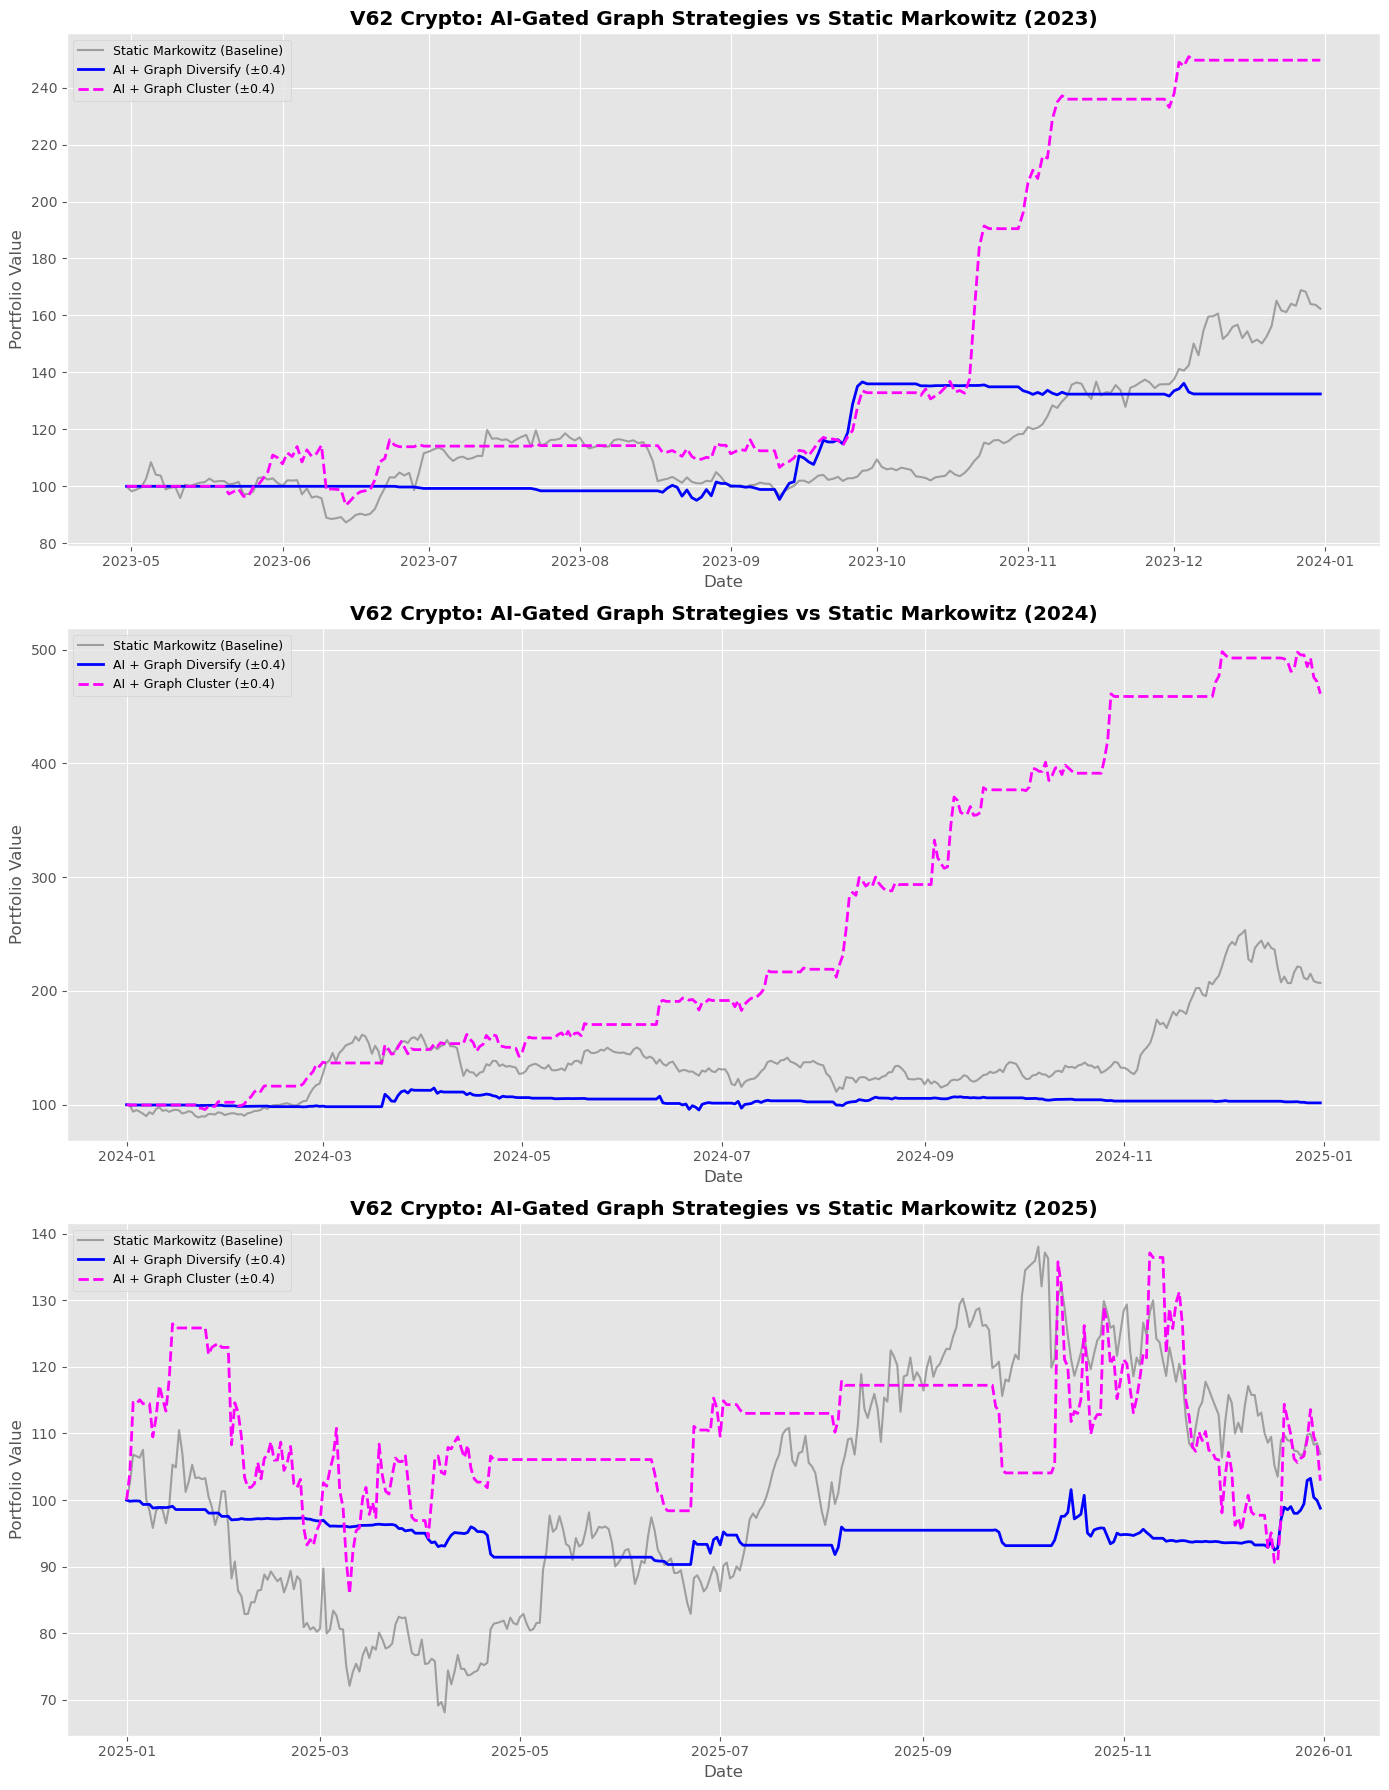

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for i, year in enumerate(years):
    axes[i].plot(results[year]['Static']['value'].index, results[year]['Static']['value']['Portfolio_Value'], 
                label='Static Markowitz (Baseline)', color='gray', alpha=0.7)
    axes[i].plot(results[year]['Diversify']['value'].index, results[year]['Diversify']['value']['Portfolio_Value'], 
                label='AI + Graph Diversify (±0.4)', color='blue', linewidth=2)
    axes[i].plot(results[year]['Cluster']['value'].index, results[year]['Cluster']['value']['Portfolio_Value'], 
                label='AI + Graph Cluster (±0.4)', color='magenta', linestyle='--', linewidth=2)
    
    axes[i].set_title(f"V62 Crypto: AI-Gated Graph Strategies vs Static Markowitz ({year})", fontweight='bold')
    axes[i].set_ylabel("Portfolio Value")
    axes[i].set_xlabel("Date")
    axes[i].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('performance_comparison_curves.png')
plt.show()

## 6. Visualisasi 2: Metrics Bar Charts

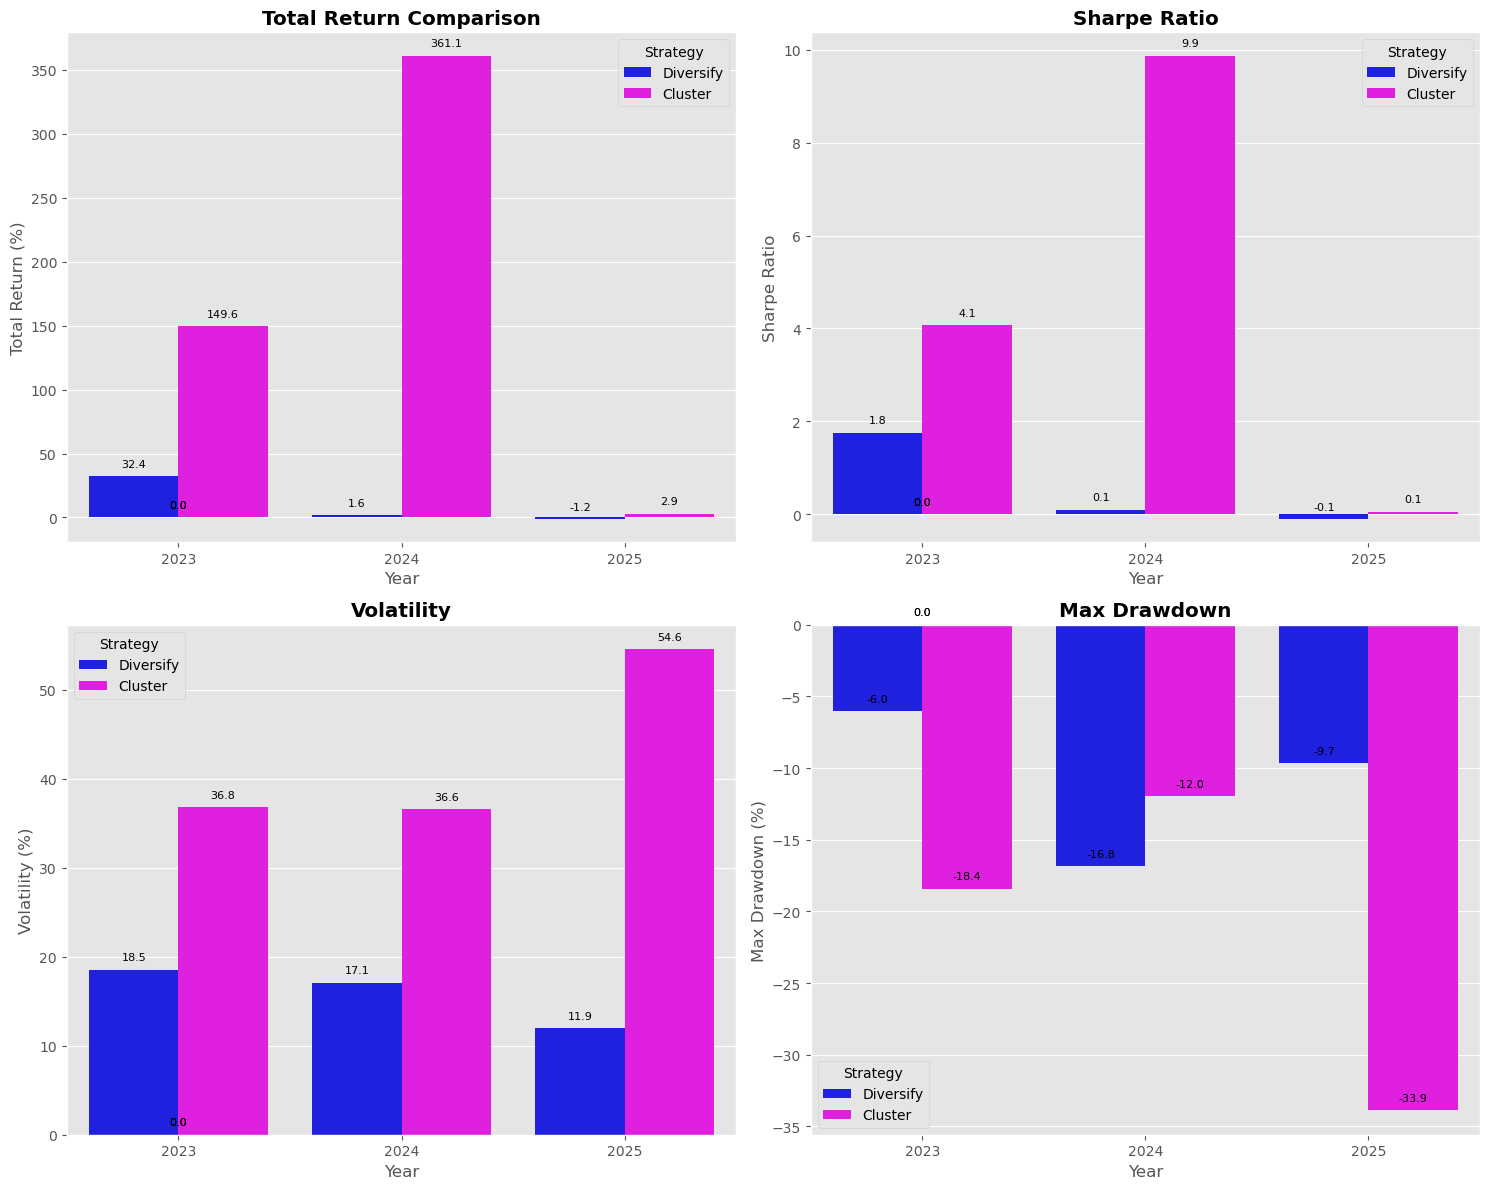

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
metrics_to_plot = ['Total Return (%)', 'Sharpe Ratio', 'Volatility (%)', 'Max Drawdown (%)']
colors = {'Cluster': 'blue', 'Diversify': 'magenta', 'Static': 'gray'}

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    plot_df = metrics_df[metrics_df['Strategy'] != 'Static'] # Focus on AI strategies
    sns.barplot(data=plot_df, x='Year', y=metric, hue='Strategy', ax=ax, palette=['blue', 'magenta'])
    ax.set_title(metric.replace('(%)', '').strip() + (" Comparison" if i==0 else ""), fontweight='bold')
    
    # Add values on top
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.1f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points', fontsize=8)

plt.tight_layout()
plt.savefig('metrics_comparison_bars.png')
plt.show()

## 7. Statistical Significance (Paired T-Test)

Menguji apakah return harian berbeda secara signifikan antara Cluster dan Diversify.

In [8]:
print("="*60)
print("PAIRED T-TEST: DAILY RETURNS SIGNIFICANCE")
print("="*60)

combined_div = pd.concat([results[y]['Diversify']['value']['Portfolio_Value'].pct_change().dropna() for y in years])
combined_cls = pd.concat([results[y]['Cluster']['value']['Portfolio_Value'].pct_change().dropna() for y in years])

t_stat, p_val = stats.ttest_rel(combined_cls, combined_div)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.6f}")
if p_val < 0.05:
    print("STATUS: SIGNIFIKAN (Performa Cluster secara statistik berbeda nyata dari Diversify)")
else:
    print("STATUS: TIDAK SIGNIFIKAN (Perbedaan performa mungkin karena kebetulan)")

PAIRED T-TEST: DAILY RETURNS SIGNIFICANCE
T-Statistic: 3.0464
P-Value: 0.002378
STATUS: SIGNIFIKAN (Performa Cluster secara statistik berbeda nyata dari Diversify)


## 8. Visualisasi 3: Portfolio Composition 2024 (Deep Dive)

Melihat koin apa saja yang mendominasi saat lonjakan performa 2024.

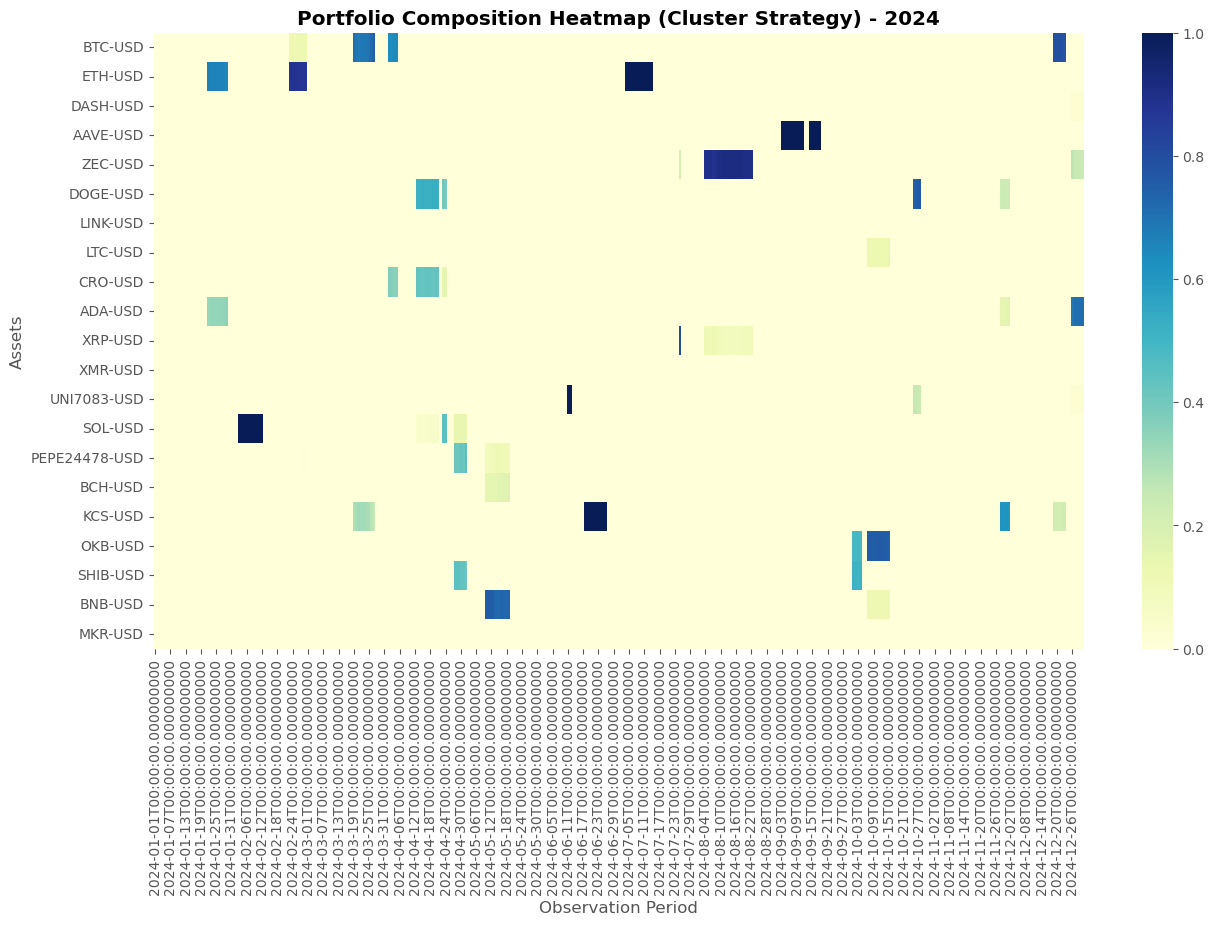

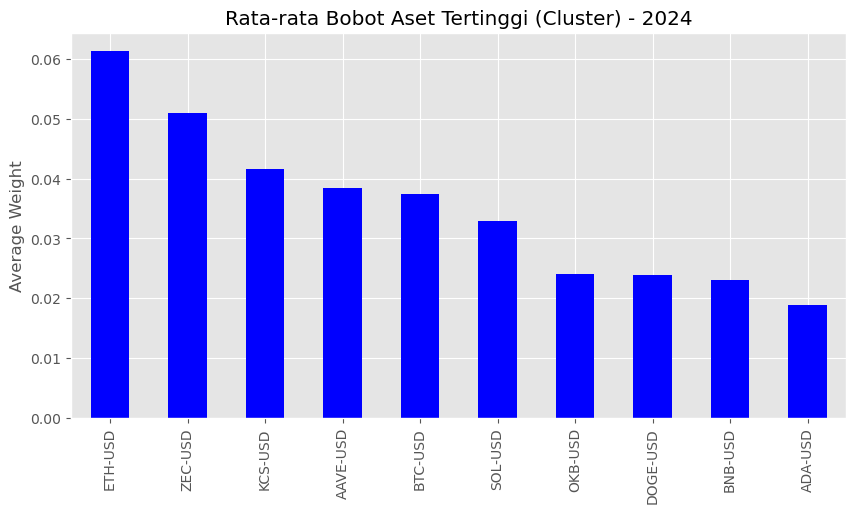

In [9]:
alloc_2024 = results[2024]['Cluster']['alloc']
df_alloc = pd.DataFrame(alloc_2024).T.fillna(0)
active_assets = [a for a in df_alloc.columns if a != 'CASH' and df_alloc[a].sum() > 0]

plt.figure(figsize=(15, 8))
sns.heatmap(df_alloc[active_assets].T, cmap="YlGnBu")
plt.title("Portfolio Composition Heatmap (Cluster Strategy) - 2024", fontweight='bold')
plt.xlabel("Observation Period")
plt.ylabel("Assets")
plt.savefig('cluster_composition_heatmap.png')
plt.show()

top_assets = df_alloc[active_assets].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
top_assets.plot(kind='bar', color='blue')
plt.title("Rata-rata Bobot Aset Tertinggi (Cluster) - 2024")
plt.ylabel("Average Weight")
plt.show()